In [1]:
import importlib.util

if importlib.util.find_spec('nest_asyncio') is None:
    print('Installing nest_asnycio')
    %pip install nest_asyncio
if importlib.util.find_spec('bleak') is None:
    print('Installing bleak')
    %pip install bleak

import nest_asyncio
nest_asyncio.apply()

import asyncio
import movesense as ms
import matplotlib.pyplot as plt



# DEVICE SETTINGS

ADDRESS = "0C:8C:DC:3C:9D:19" # Movesense address

# SUBSCRIBTION SETTINGS
# Refer to API for samplerates
# https://movesense.com/docs/esw/api_reference

SENSOR = ms.Sensor.IMU9

SAMPLERATE = 104 # Depends on sensor

REC_LENGTH = 60 # In seconds

START_DELAY = 5 # Wait N seconds after connecting

FILEPATH = "../../data/movesense/" # CSV save location (FOLDER MUST EXIST)

SAVE_TO_CSV = True # Option to disable saving data to a CSV.


device = ms.MovesenseClient(ADDRESS)

async def main():
    async with device as client:
        record = await client.subscribe(
            sensor=SENSOR, 
            samplerate=SAMPLERATE, 
            rec_length=REC_LENGTH, 
            start_delay=START_DELAY, 
            filepath=FILEPATH,
            save_to_csv=True
        )
    
        df = record.to_pandas()
        print(df.tail(5))
    
asyncio.run(main())

(ms1465) Connected
(ms1465) Recording starts in 5 seconds
(ms1465) Recording imu9 @ 104Hz
(ms1465) Recording complete
File created at: ../../data/movesense/ms1465_imu9_2025-11-06_00-02-46.csv
      Timestamp   AccX   AccY   AccZ  GyroX  GyroY  GyroZ  MagnX  MagnY  MagnZ
6235        NaN  0.385  0.436  9.959  0.424  0.438  9.995   2.59   1.40   0.84
6236   169209.0  0.433  0.445  9.966  0.421  0.443  9.976   2.45   1.19   0.77
6237        NaN  0.424  0.416  9.935  0.433  0.424  9.976   2.45   1.26   0.77
6238        NaN  0.445  0.436  9.974  0.459  0.419  9.969   2.66   1.33   0.84
6239        NaN  0.440  0.450  9.959  0.440  0.421  9.943   2.66   1.33   0.77
(ms1465) Disconnected


✅ Suodatettu data tallennettu: ../../data/movesense/testeja/data_for_test(60s)_filtered.csv


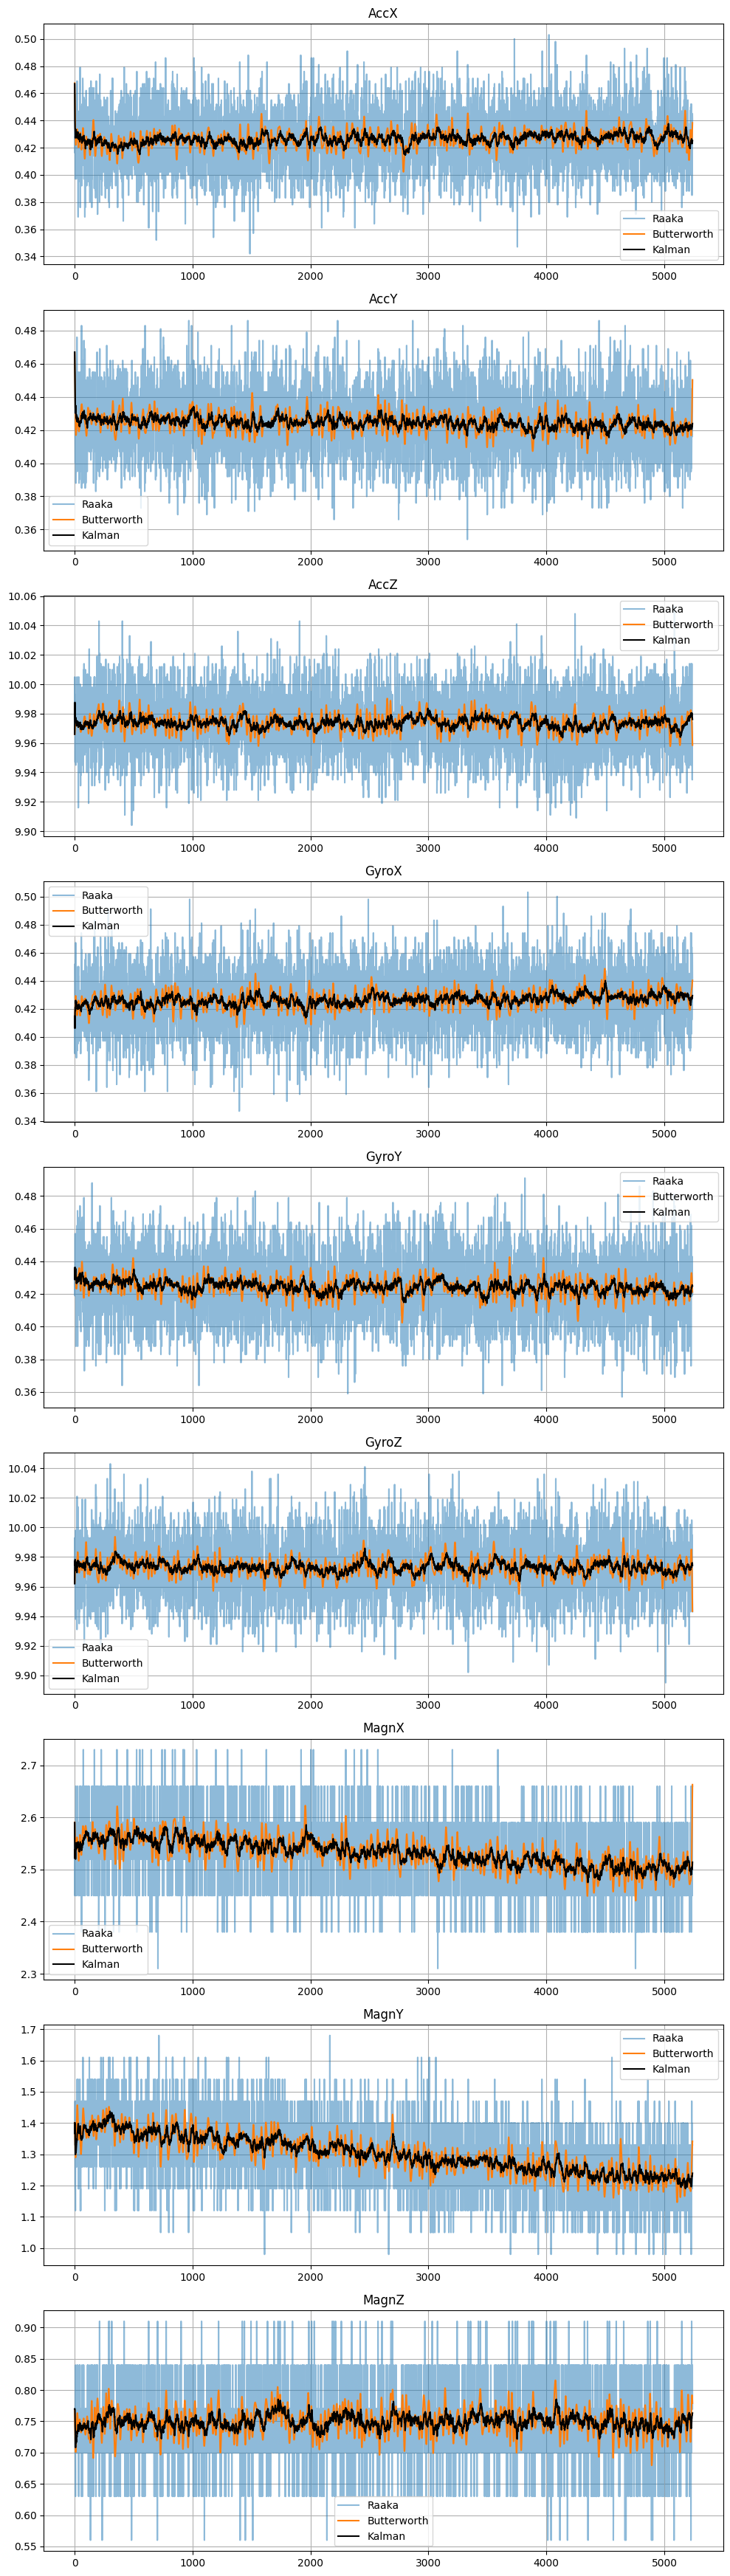

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# --- Kalman-suodatin (yksinkertainen) ---
class SimpleKalman:
    def __init__(self, process_var=1e-4, meas_var=0.05):
        self.process_var = process_var
        self.meas_var = meas_var
        self.initialized = False

    def filter(self, data):
        estimates = []
        for measurement in data:
            if not self.initialized:
                self.posteri_estimate = measurement  # <-- старт с реального значения
                self.posteri_error_estimate = 1.0
                self.initialized = True
            priori_estimate = self.posteri_estimate
            priori_error_estimate = self.posteri_error_estimate + self.process_var
            kalman_gain = priori_error_estimate / (priori_error_estimate + self.meas_var)
            self.posteri_estimate = priori_estimate + kalman_gain * (measurement - priori_estimate)
            self.posteri_error_estimate = (1 - kalman_gain) * priori_error_estimate
            estimates.append(self.posteri_estimate)
        return np.array(estimates)

# --- Butterworth-suodatin ---
def butter_lowpass_filter(data, cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

# --- Pääfunktio ---
def process_imu_data(filename, fs=104, cutoff=5, order=4, save=True, plot=True, drop_n=1000):
    df = pd.read_csv(filename)

    if len(df) > drop_n:
        df = df.iloc[drop_n:].reset_index(drop=True)
    else:
        raise ValueError(f"Tiedosto on liian lyhyt ({len(df)} riviä) - ei voi poistaa {drop_n} riviä.")


    columns = ['AccX','AccY','AccZ','GyroX','GyroY','GyroZ','MagnX','MagnY','MagnZ']

    for col in columns:
        raw = df[col].values
        df[f'{col}_butter'] = butter_lowpass_filter(raw, cutoff, fs, order)
        kalman = SimpleKalman()
        df[f'{col}_kalman'] = kalman.filter(raw)

    if save:
        output_name = filename.replace('.csv', '_filtered.csv')
        df.to_csv(output_name, index=False)
        print(f"✅ Suodatettu data tallennettu: {output_name}")

    if plot:
        # Näytetään esim. AccX, AccY, AccZ ennen/jälkeen suodatuksen
        fig, axes = plt.subplots(9, 1, figsize=(10, 35))
        for i, axis in enumerate(['AccX', 'AccY', 'AccZ', 'GyroX', 'GyroY', 'GyroZ', 'MagnX', 'MagnY', 'MagnZ']):
            axes[i].plot(df.index, df[axis], alpha=0.5, label='Raaka')
            axes[i].plot(df.index, df[f'{axis}_butter'], label='Butterworth')
            axes[i].plot(df.index, df[f'{axis}_kalman'], label='Kalman', color='black')
            axes[i].set_title(axis)
            axes[i].legend()
            axes[i].grid(True)
        plt.tight_layout()
        plt.show()

    return df

# --- Käyttöesimerkki ---
if __name__ == "__main__":
    
    df_filtered = process_imu_data("../../data/movesense/testeja/data_for_test(60s).csv")


In [6]:
# calibration_process.py
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from textwrap import dedent

G = 9.81


def read_files(file_list=None, orientation_col=None):
    """
    Если file_list содержит 6 файлов, каждый файл считается отдельной ориентацией.
    Ожидаемые имена файлов/ориентаций (в любом порядке): up, down, left, right, front, back
    Либо передать один файл с колонкой orientation (значения: up/down/left/right/front/back).
    """
    records = {}
    if file_list is None:
        raise ValueError("Передайте список файлов или путь к файлу с колонкой orientation.")
    # Если передали одиночный файл с колонкой orientation:
    if len(file_list) == 1 and orientation_col is not None:
        df = pd.read_csv(file_list[0])
        if orientation_col not in df.columns:
            raise ValueError(f"Колонка {orientation_col} не найдена в {file_list[0]}")
        for ori in ['up','down','left','right','front','back']:
            seg = df[df[orientation_col].astype(str).str.lower() == ori]
            if len(seg) > 0:
                records[ori] = seg[['AccX','AccY','AccZ']].dropna().reset_index(drop=True)
    else:
        # Ожидаем 6 файлов; пытаемся угадать ориентацию по имени файла
        for f in file_list:
            name = os.path.basename(f).lower()
            assigned = None
            for ori in ['up','down','left','right','front','back']:
                if ori in name:
                    assigned = ori
                    break
            if assigned is None:
                # если не нашли, журналим и используем имя файла как ключ
                assigned = os.path.splitext(os.path.basename(f))[0]
            records[assigned] = pd.read_csv(f)[['AccX','AccY','AccZ']].dropna().reset_index(drop=True)
    return records

def compute_stats(records, stat_len=None):
    """
    records: dict[orientation] -> DataFrame(AccX,AccY,AccZ)
    stat_len: как много первых N точек использовать из каждого файла (None = весь файл)
    """
    results = {}
    for ori, df in records.items():
        seg = df if stat_len is None else df.iloc[:stat_len]
        mean = seg.mean()
        std = seg.std()
        mag = np.sqrt((seg[['AccX','AccY','AccZ']]**2).sum(axis=1)).mean()
        results[ori] = {
            'n': len(seg),
            'AccX_mean': mean['AccX'], 'AccX_std': std['AccX'],
            'AccY_mean': mean['AccY'], 'AccY_std': std['AccY'],
            'AccZ_mean': mean['AccZ'], 'AccZ_std': std['AccZ'],
            'Mag_mean': mag
        }
    return pd.DataFrame(results).T

def compute_bias_scale(stats_df):
    """
    Предполагаем пары: up<->down => Z, left<->right => X, front<->back => Y
    bias = (pos + neg) / 2
    scale = (pos - neg) / (2*g)
    """
    def get_val(df, name):
        return df[name] if name in df.index else None

    axes = {'X':('left','right'),'Y':('front','back'),'Z':('up','down')}
    out = {}
    for ax, (pos, neg) in axes.items():
        if pos in stats_df.index and neg in stats_df.index:
            posm = stats_df.at[pos, f'Acc{ax}_mean']
            negm = stats_df.at[neg, f'Acc{ax}_mean']
            posstd = stats_df.at[pos, f'Acc{ax}_std']
            negstd = stats_df.at[neg, f'Acc{ax}_std']
            bias = (posm + negm) / 2.0
            # scale: (pos - neg) should be ~ 2*g -> scale factor ~ (pos-neg)/(2*g)
            scale = (posm - negm) / (2.0 * G)
            out[ax] = {
                'pos_mean': posm, 'pos_std': posstd,
                'neg_mean': negm, 'neg_std': negstd,
                'bias': bias, 'scale': scale
            }
        else:
            out[ax] = {'error': f"missing pair {pos}/{neg}"}
    return pd.DataFrame(out).T

def compute_gyro_bias(file_list, stat_len=200, out_prefix="gyro_bias"):
    """
    Вычисление bias гироскопа по первым stat_len отсчётам из каждого файла.
    """
    results = []
    for f in file_list:
        name = f.split("/")[-1].replace(".csv", "")
        df = pd.read_csv(f)
        seg = df[['GyroX','GyroY','GyroZ']].iloc[:stat_len]
        means = seg.mean()
        stds = seg.std()
        results.append({
            'file': name,
            'GyroX_mean': means['GyroX'],
            'GyroY_mean': means['GyroY'],
            'GyroZ_mean': means['GyroZ'],
            'GyroX_std': stds['GyroX'],
            'GyroY_std': stds['GyroY'],
            'GyroZ_std': stds['GyroZ']
        })
    res_df = pd.DataFrame(results)
    # Средний bias по всем ориентациям:
    avg_bias = res_df[['GyroX_mean','GyroY_mean','GyroZ_mean']].mean()
    print("\n=== Gyroscope static bias summary ===")
    print(res_df.round(5))
    print("\nMean bias across all files:")
    print(avg_bias.round(5))
    res_df.to_csv(out_prefix + ".csv", index=False)

    # Заключение
    limit = 0.1  # °/s, можно скорректировать по необходимости
    print("\nEvaluation:")
    for axis in ['X','Y','Z']:
        val = avg_bias[f'Gyro{axis}_mean']
        status = "OK ✅" if abs(val) < limit else "High bias ⚠️"
        print(f"Gyro{axis}: {val:.3f} °/s → {status}")

    print(f"\nSaved results to {out_prefix}.csv")
    return avg_bias, res_df


def save_report(stats_df, bs_df, out_prefix='calib_result'):
    stats_df.to_csv(out_prefix + '_stationary_stats.csv')
    bs_df.to_csv(out_prefix + '_bias_scale.csv')
    # Простой график: means per orientation
    fig, axs = plt.subplots(3,1, figsize=(8,10))
    for i, axis in enumerate(['AccX','AccY','AccZ']):
        means = [stats_df.at[ori, f'{axis}_mean'] if ori in stats_df.index else np.nan for ori in stats_df.index]
        axs[i].bar(range(len(stats_df.index)), means)
        axs[i].set_xticks(range(len(stats_df.index)))
        axs[i].set_xticklabels(stats_df.index, rotation=45)
        axs[i].set_ylabel(axis + ' mean (m/s^2)')
        axs[i].grid(True, alpha=0.2)
    plt.tight_layout()
    fig.savefig(out_prefix + '_means.png', dpi=150)
    plt.close(fig)
    print("Saved:", out_prefix + '_stationary_stats.csv,', out_prefix + '_bias_scale.csv,', out_prefix + '_means.png')

def main(files, orientation_col=None, stat_len=200, out_prefix='calib_result'):
    recs = read_files(files, orientation_col=orientation_col)
    if len(recs) < 6:
        print("Warning: detected <6 orientations. Found:", list(recs.keys()))
    stats = compute_stats(recs, stat_len=stat_len)
    bs = compute_bias_scale(stats)
    print("\n=== Stationary stats (sample) ===")
    print(stats.round(4))
    print("\n=== Bias & Scale per axis ===")
    print(bs.round(6))
    save_report(stats, bs, out_prefix=out_prefix)
    return stats, bs

if __name__ == '__main__':
    

    stats, bs = main([
        "../../data/movesense/testeja/filtered/data_for_test(60s)_filtered.csv",
    ], out_prefix="calib_movesense_v1")

    avg_bias, gyro_table = compute_gyro_bias([
        "../../data/movesense/testeja/filtered/data_for_test(60s)_filtered.csv",
    ], stat_len=200, out_prefix="gyro_bias_movesense_v1")




=== Stationary stats (sample) ===
                                 n  AccX_mean  AccX_std  AccY_mean  AccY_std  \
data_for_test(60s)_filtered  200.0     0.4252    0.0229     0.4272    0.0195   

                             AccZ_mean  AccZ_std  Mag_mean  
data_for_test(60s)_filtered     9.9732    0.0195    9.9915  

=== Bias & Scale per axis ===
                     error
X  missing pair left/right
Y  missing pair front/back
Z     missing pair up/down
Saved: calib_movesense_v1_stationary_stats.csv, calib_movesense_v1_bias_scale.csv, calib_movesense_v1_means.png

=== Gyroscope static bias summary ===
                          file  GyroX_mean  GyroY_mean  GyroZ_mean  GyroX_std  \
0  data_for_test(60s)_filtered     0.42293     0.42756     9.97479    0.02011   

   GyroY_std  GyroZ_std  
0    0.02003    0.01993  

Mean bias across all files:
GyroX_mean    0.42293
GyroY_mean    0.42756
GyroZ_mean    9.97479
dtype: float64

Evaluation:
GyroX: 0.423 °/s → High bias ⚠️
GyroY: 0.428 °/s → Hig